# Training, Validation, and Test Splits

A neural-network example showing how separate validation and test sets support model selection and unbiased evaluation.

In [1]:
import numpy as np
import tensorflow as tf
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [2]:
# Breast Cancer dataset
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

In [3]:
# Split the data into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

## Why a validation set?

Best practice requires that we split our dataset into:
* Training
* Validation
* Testing

Our goal is to predict how our model will do in the real world. That is, how does our model perform on instances it hasn't already seen in training. 

Specifically, we are interested in how well our model *generalizes* to new instances. This is why we have a test set of instances the model has not already seen.

*Why do we need a validation set?*

*Why not just use our test set for all evaluation?*

All models have some number of *hyperparameters*. These are choices we can make about the model itself. With KNN, we can choose *k*. With neural nets, we have number of layers, number of units in each layer and so forth.

Changing these hyperparameters can lead to different performance on the test set.

If we try different hyperparameters to get good performance on the test set, then our model is *learning the test set* as well as the training set. Information is *leaking* from the test set into our model.

*Why is tuning the model for the test set bad?*

If our test set is not representative of the real world, then we may fool ourselves into thinking that our model is improving, when it actually may perform much worse on new instances.

To avoid developing unrealistic expectations from our model, we need to use a different dataset, the *validation* set, for selecting good hyperparameters.


In [4]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(2, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [5]:
history = model.fit(X_train, 
                    y_train, 
                    epochs=20, 
                    validation_data=(X_val, y_val),
                    verbose=1)

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3711 - loss: 21.3326 - val_accuracy: 0.3882 - val_loss: 18.0163
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3637 - loss: 12.1975 - val_accuracy: 0.2706 - val_loss: 7.8717
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3623 - loss: 6.2107 - val_accuracy: 0.4941 - val_loss: 3.7860
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6166 - loss: 2.4166 - val_accuracy: 0.7412 - val_loss: 0.9462
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7151 - loss: 1.2751 - val_accuracy: 0.8353 - val_loss: 0.8704
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8155 - loss: 0.9236 - val_accuracy: 0.8588 - val_loss: 0.5213
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8495 - loss: 0.5849 - val_accuracy: 0.8353 - val_loss: 0.4831
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8577 - loss: 0.4882 - val_accuracy: 0.8588 - val_

test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy}")

In [6]:
print(history.history)

{'accuracy': [0.30150753259658813, 0.3316583037376404, 0.3919597864151001, 0.6130653023719788, 0.7512562870979309, 0.8241205811500549, 0.8442211151123047, 0.8517587780952454, 0.8718593120574951, 0.8693467378616333, 0.8743718862533569, 0.8743718862533569, 0.8668341636657715, 0.8743718862533569, 0.8517587780952454, 0.8994975090026855, 0.8819095492362976, 0.9221105575561523, 0.8542713522911072, 0.9020100235939026], 'loss': [19.921001434326172, 11.046819686889648, 5.190212726593018, 2.1561026573181152, 0.9871971011161804, 0.7560065984725952, 0.5632612705230713, 0.5352700352668762, 0.44522446393966675, 0.49187761545181274, 0.4162146747112274, 0.4444204866886139, 0.4132862687110901, 0.4383349120616913, 0.43543127179145813, 0.30556753277778625, 0.3682897090911865, 0.26158827543258667, 0.4327264130115509, 0.28900277614593506], 'val_accuracy': [0.38823530077934265, 0.2705882489681244, 0.4941176474094391, 0.7411764860153198, 0.8352941274642944, 0.8588235378265381, 0.8352941274642944, 0.858823537

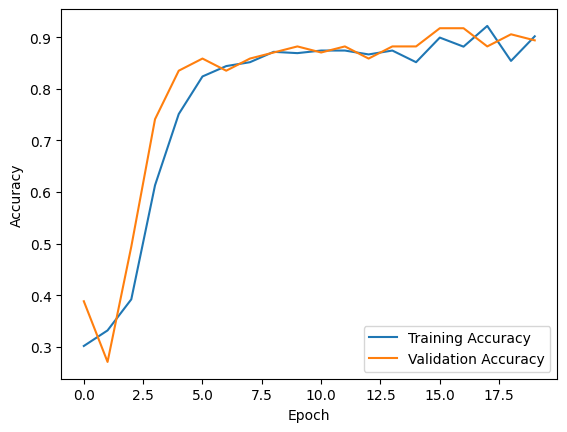

In [7]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
